In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("manh123df/deap-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.73G/2.73G [01:09<00:00, 42.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/manh123df/deap-dataset/versions/1


In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load all data and labels into memory
data_path = path + "/deap-dataset/data_preprocessed_python"
data_list, label_list = [], []


# Range can extend to 33 for files s01.dat to s32.dat. Truncate for testing purposes.
for i in range(1, 5):
    with open(f"{data_path}/s{i:02d}.dat", "rb") as f:
        subject = pickle.load(f, encoding="latin1")
    data_list.append(subject["data"])    # (40, 40, 8064)
    label_list.append(subject["labels"]) # (40, 4)

data   = np.concatenate(data_list,  axis=0)  # (1280, 40, 8064)
labels = np.concatenate(label_list, axis=0)  # (1280, 4)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)


Data shape: (160, 40, 8064)
Labels shape: (160, 4)


# Model 1: Traditional CNN

### Imports and data prep


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# --- Windowing ---
WINDOW = 128
n_trials, n_channels, n_times = data.shape
n_windows = n_times // WINDOW  # 63 windows per trial

# Shape: (n_trials, n_windows, n_channels, WINDOW)
X_by_trial = data[:, :, :n_windows * WINDOW].reshape(n_trials, n_channels, n_windows, WINDOW).transpose(0, 2, 1, 3)

# Binary labels for all 4 categories (>5 = high, <=5 = low)
label_names = ["valence", "arousal", "dominance", "liking"]
y_labels = {name: (labels[:, i] > 5).astype(int) for i, name in enumerate(label_names)}

# One trial-level split shared across all categories (stratify on valence)
train_trials, test_trials = train_test_split(
    np.arange(n_trials), test_size=0.2, random_state=42, stratify=y_labels["valence"]
)

X_train = X_by_trial[train_trials].reshape(-1, n_channels, WINDOW)
X_test  = X_by_trial[test_trials].reshape(-1, n_channels, WINDOW)

mean = X_train.mean(axis=(0, 2), keepdims=True)
std  = X_train.std(axis=(0, 2), keepdims=True) + 1e-6
X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std # use train stats to avoid data leakage

to_tensor = lambda arr: torch.tensor(arr, dtype=torch.float32).unsqueeze(1)
X_train_t = to_tensor(X_train)
X_test_t  = to_tensor(X_test)

# Build a DataLoader pair for each category
dataloaders = {}
for name, y in y_labels.items():
    y_train = np.repeat(y[train_trials], n_windows)
    y_test  = np.repeat(y[test_trials],  n_windows)
    train_ds = TensorDataset(X_train_t, torch.tensor(y_train, dtype=torch.long))
    test_ds  = TensorDataset(X_test_t,  torch.tensor(y_test,  dtype=torch.long))
    dataloaders[name] = {
        "train": DataLoader(train_ds, batch_size=64, shuffle=True),
        "test":  DataLoader(test_ds,  batch_size=64),
        "balance": y.mean(),
    }
    print(f"{name:10s}  train={len(train_ds)}  test={len(test_ds)}  class balance={y.mean():.2f}")

valence     train=8064  test=2016  class balance=0.23
arousal     train=8064  test=2016  class balance=0.19
dominance   train=8064  test=2016  class balance=0.51
liking      train=8064  test=2016  class balance=0.74


### Define EEGNet model

In [ ]:
class EEGNet(nn.Module):
    def __init__(self, n_classes=2, n_channels=40, n_times=128, F1=8, D=2, F2=16, dropout=0.5):
        super().__init__()
        # Block 1: temporal conv across all channels
        self.temporal = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1),
        )
        # Block 2: depthwise spatial conv — one filter per EEG channel
        self.spatial = nn.Sequential(
            nn.Conv2d(F1, F1 * D, kernel_size=(n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),
        )
        # Block 3: separable temporal conv
        self.separable = nn.Sequential(
            nn.Conv2d(F1 * D, F2, kernel_size=(1, 16), padding=(0, 8), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout),
        )
        # Classifier — compute flattened size dynamically
        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_times)
            out = self.separable(self.spatial(self.temporal(dummy)))
            flat = out.flatten(1).shape[1]
        self.classifier = nn.Linear(flat, n_classes)

    def forward(self, x):
        x = self.temporal(x)
        x = self.spatial(x)
        x = self.separable(x)
        return self.classifier(x.flatten(1))

### Define hyperparameters


In [ ]:
EPOCHS = 100
lr = 1e-3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vmodel = EEGNet().to(device)
amodel = EEGNet().to(device)
dmodel = EEGNet().to(device)
lmodel = EEGNet().to(device)

models = {"valence": vmodel, "arousal": amodel, "dominance": dmodel, "liking": lmodel}
loss_lists = {name: [] for name in label_names}

optimizers  = {name: optim.Adam(m.parameters(), lr=lr) for name, m in models.items()}
schedulers  = {name: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS) for name, opt in optimizers.items()}
criterions  = {
    name: nn.CrossEntropyLoss(
        weight=(1.0 / torch.tensor([1 - dataloaders[name]["balance"],
                                        dataloaders[name]["balance"]], dtype=torch.float32)).to(device),
        label_smoothing=0.1
    )
    for name in label_names
}

### Loss and training loop

In [ ]:
def run_epoch(model, criterion, optimizer, loader, train=True):
    model.train(train)
    total_loss, correct = 0, 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(yb)
            correct += (out.argmax(1) == yb).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n

for epoch in range(1, EPOCHS + 1):
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}", end="")
    for name in label_names:
        tr_loss, tr_acc = run_epoch(models[name], criterions[name], optimizers[name], dataloaders[name]["train"], train=True)
        va_loss, va_acc = run_epoch(models[name], criterions[name], optimizers[name], dataloaders[name]["test"],  train=False)
        loss_lists[name].append(tr_loss)
        schedulers[name].step()
        if epoch % 10 == 0:
            print(f"  {name}: {tr_acc:.3f}/{va_acc:.3f}", end="")
    if epoch % 5 == 0:
        print()


Epoch  10  valence: 0.783/0.582  arousal: 0.664/0.519  dominance: 0.736/0.760  liking: 0.735/0.630

Epoch  20  valence: 0.806/0.583  arousal: 0.724/0.587  dominance: 0.760/0.703  liking: 0.754/0.660

Epoch  30  valence: 0.820/0.601  arousal: 0.762/0.577  dominance: 0.777/0.707  liking: 0.775/0.649

Epoch  40  valence: 0.820/0.604  arousal: 0.779/0.620  dominance: 0.781/0.723  liking: 0.780/0.641

Epoch  50  valence: 0.842/0.619  arousal: 0.795/0.626  dominance: 0.796/0.722  liking: 0.790/0.637

Epoch  60  valence: 0.835/0.627  arousal: 0.805/0.618  dominance: 0.802/0.722  liking: 0.792/0.650

Epoch  70  valence: 0.851/0.611  arousal: 0.810/0.620  dominance: 0.805/0.742  liking: 0.798/0.636

Epoch  80  valence: 0.848/0.608  arousal: 0.814/0.610  dominance: 0.814/0.725  liking: 0.800/0.656

Epoch  90  valence: 0.846/0.605  arousal: 0.809/0.644  dominance: 0.811/0.724  liking: 0.800/0.653

Epoch 100  valence: 0.846/0.609  arousal: 0.811/0.617  dominance: 0.817/0.733  liking: 0.798/0.659


### Calculate and display final metrics

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def calculate_metrics(model, dataloader):
    model.eval() # Set the model to evaluation mode
    all_preds = []
    all_labels = []
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for xb, yb in dataloader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            probabilities = torch.softmax(outputs, dim=1)
            predictions = torch.argmax(probabilities, dim=1)

            all_preds.extend(probabilities[:, 1].cpu().numpy()) # Probability of class 1
            all_labels.extend(yb.cpu().numpy())

            correct_predictions += (predictions == yb).sum().item()
            total_samples += yb.size(0)

    accuracy = correct_predictions / total_samples

    # Calculate MAE using the user's specified formula
    mae = np.mean(np.abs(np.array(all_labels) - np.array(all_preds)))
    # Calculate RMSE using the user's specified formula
    mse = np.mean((np.array(all_labels) - np.array(all_preds))**2)
    rmse = np.sqrt(mse)

    return accuracy, mae, rmse

for name in label_names:
    print(f"\n--- Metrics for {name.capitalize()} ---")

    # Calculate metrics for the training set
    train_acc, train_mae, train_rmse = calculate_metrics(models[name], dataloaders[name]["train"])
    print(f"Training Accuracy: {train_acc:.3f}")

    # Calculate metrics for the validation (test) set
    val_acc, val_mae, val_rmse = calculate_metrics(models[name], dataloaders[name]["test"])
    print(f"Validation Accuracy: {val_acc:.3f}")
    print(f"Overall MAE: {val_mae:.3f}")
    print(f"Overall RMSE: {val_rmse:.3f}")


--- Metrics for Valence ---
Training Accuracy: 0.884
Validation Accuracy: 0.609
Overall MAE: 0.416
Overall RMSE: 0.517

--- Metrics for Arousal ---
Training Accuracy: 0.829
Validation Accuracy: 0.617
Overall MAE: 0.433
Overall RMSE: 0.514

--- Metrics for Dominance ---
Training Accuracy: 0.858
Validation Accuracy: 0.733
Overall MAE: 0.348
Overall RMSE: 0.421

--- Metrics for Liking ---
Training Accuracy: 0.828
Validation Accuracy: 0.659
Overall MAE: 0.405
Overall RMSE: 0.483


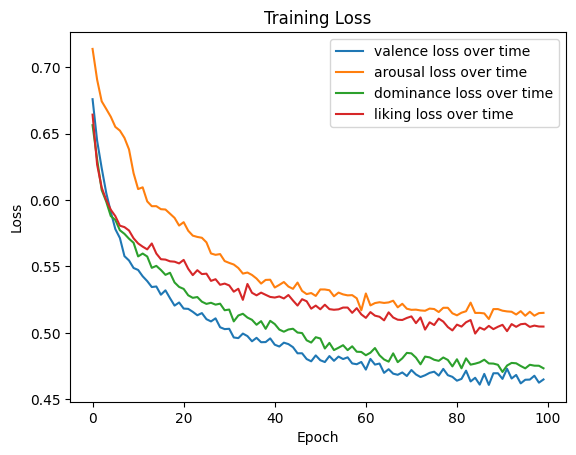

In [ ]:
for name in label_names:
    plt.plot(loss_lists[name], label=f"{name} loss over time")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.savefig("loss.svg")
plt.show()